In [1]:
import numpy as np
import pandas as pd

In [16]:

cpi = pd.read_csv("Inflation.csv")[["REF_DATE", "GEO", "Products and product groups", "VALUE"]]
cpi = cpi[(cpi["GEO"] == "Canada") & (cpi["Products and product groups"] == "All-items")].copy()


cpi["REF_DATE"] = pd.to_datetime(cpi["REF_DATE"])
cpi = cpi.sort_values("REF_DATE").set_index("REF_DATE").rename(columns={"VALUE": "CPI"})


infl_mom = (np.log(cpi["CPI"]) - np.log(cpi["CPI"].shift(1))) * 100

infl_yoy = (np.log(cpi["CPI"]) - np.log(cpi["CPI"].shift(12))) * 100

iq_mom = infl_mom.dropna().resample("Q").mean()
iq_yoy = infl_yoy.dropna().resample("Q").mean()

iq_mom.index = iq_mom.index.to_period("Q")
iq_yoy.index = iq_yoy.index.to_period("Q")

C:\Users\logc0\AppData\Local\Temp\ipykernel_19708\2257329152.py:13: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  iq_mom = infl_mom.dropna().resample("Q").mean()
C:\Users\logc0\AppData\Local\Temp\ipykernel_19708\2257329152.py:14: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  iq_yoy = infl_yoy.dropna().resample("Q").mean()


In [32]:
cpi_quarterly_growth.to_csv("cpi_quarterly_growth.csv", index=True)

In [31]:
cpi_quarterly_growth.head()

,REF_DATE,qoq_pct
0,1992Q1,NaN
1,1992Q2,0.720288
2,1992Q3,0.357569
3,1992Q4,0.395883
4,1993Q1,0.670347


In [11]:
gdp = pd.read_csv("gdp_componet_growth.csv")

In [12]:
gdp.head()

,REF_DATE,Final consumption expenditure,Gross fixed capital formation,General governments final consumption expenditure,Exports of goods and services,Less: imports of goods and services
0,1990-04-01,-0.011299,-0.024464,-0.011918,0.035751,0.002427
1,1990-07-01,0.006715,-0.027821,0.021849,-0.005814,-0.019089
2,1990-10-01,0.000968,-0.036518,0.011083,-0.026901,-0.013482
3,1991-01-01,-0.015716,0.008323,-0.005196,-0.020613,0.002434
4,1991-04-01,0.017263,-0.011490,0.018622,0.043273,0.019098


In [ ]:
fname = "commdity_price_index.csv"  

with open(fname, encoding="utf-8") as f:
    lines = f.readlines()
start = next(i for i, s in enumerate(lines) if s.strip().startswith('"date"'))
data = [lines[start].strip()]
for s in map(str.strip, lines[start+1:]):
    if not (s.startswith('"') and s[1:2].isdigit()):  
        break
    data.append(s)


df_m = pd.read_csv(io.StringIO("\n".join(data)))
df_m["date"] = pd.to_datetime(df_m["date"])
df_m = df_m.set_index("date")


df_q = df_m.resample("Q").mean().reset_index()
df_q["quarter"] = df_q["date"].dt.to_period("Q").astype(str)

df_q.head()

C:\Users\logc0\AppData\Local\Temp\ipykernel_19708\390120480.py:21: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_q = df_m.resample("Q").mean().reset_index()


,date,M.BCPI,M.BCNE,M.ENER,M.MTLS,M.FOPR,M.AGRI,M.FISH,quarter
0,1972-03-31,100.503333,100.626667,99.943333,100.706667,100.120000,101.243333,95.953333,1972Q1
1,1972-06-30,101.713333,102.093333,100.000000,101.110000,102.070000,103.086667,93.366667,1972Q2
2,1972-09-30,104.770000,105.633333,100.913333,101.543333,105.146667,109.183333,101.463333,1972Q3
3,1972-12-31,108.200000,109.733333,101.460000,102.443333,106.986667,117.880000,116.536667,1972Q4
4,1973-03-31,118.013333,121.170000,104.523333,113.046667,115.163333,134.493333,116.193333,1973Q1


In [57]:
commdity_price_index = df_q.copy()

In [21]:
commdity_price_index .to_csv("commdity_price_index.csv", index=False)

In [33]:

df = pd.read_csv("unemployment.csv")


df.columns = ['date', 'unemployment']


df['date'] = pd.to_datetime(df['date'])


df['unemployment'] = pd.to_numeric(df['unemployment'], errors='coerce')


df = df.dropna(subset=['unemployment'])


df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.to_period('Q')


quarterly_avg = df.groupby('quarter')['unemployment'].mean().reset_index()


yearly_avg = df.groupby('year')['unemployment'].mean().reset_index()


print("Quarterly Average Unemployment Rate:")
print(quarterly_avg)

print("\nYearly Average Unemployment Rate:")
print(yearly_avg)

Quarterly Average Unemployment Rate:
    quarter  unemployment
0    1955Q1      4.800000
1    1955Q2      4.433333
2    1955Q3      4.066667
3    1955Q4      3.833333
4    1956Q1      3.700000
..      ...           ...
278  2024Q3      6.566667
279  2024Q4      6.733333
280  2025Q1      6.633333
281  2025Q2      6.933333
282  2025Q3      7.033333

[283 rows x 2 columns]

Yearly Average Unemployment Rate:
    year  unemployment
0   1955      4.283333
1   1956      3.300000
2   1957      4.750000
3   1958      7.133333
4   1959      5.875000
..   ...           ...
66  2021      7.483333
67  2022      5.250000
68  2023      5.383333
69  2024      6.375000
70  2025      6.866666

[71 rows x 2 columns]


In [34]:
unemploy = quarterly_avg

In [37]:
unemploy_quarterly_growth.head()

,quarter,qoq_pct
0,1955Q1,NaN
1,1955Q2,-7.638896
2,1955Q3,-8.270662
3,1955Q4,-5.737721
4,1956Q1,-3.478252


In [39]:
pop = pd.read_csv("population_quarterly.csv")

In [40]:
pop.head()

,quarter,population_quarterly
0,1990Q1,54869230
1,1990Q2,55075850
2,1990Q3,55323339
3,1990Q4,55555891
4,1991Q1,55650011


In [41]:
pg = pop.copy()
pg['quarter'] = pd.PeriodIndex(pg['quarter'], freq='Q')
pg = pg.sort_values('quarter').reset_index(drop=True)
pg['qoq_pct'] = pg['population_quarterly'].astype(float).pct_change()*100
pg['quarter'] = pg['quarter'].astype(str)
pop_quarterly_growth = pg[['quarter','qoq_pct']]

In [42]:
pop_quarterly_growth.head()

,quarter,qoq_pct
0,1990Q1,NaN
1,1990Q2,0.376568
2,1990Q3,0.449360
3,1990Q4,0.420351
4,1991Q1,0.169415


In [43]:
pop_quarterly_growth.to_csv("population_quarterly_growth.csv", index=False) 

In [45]:
us_gdp = pd.read_csv("us_gdp_real.csv")
us_gdp.head()

,observation_date,GDPC1
0,1947-01-01,2182.681
1,1947-04-01,2176.892
2,1947-07-01,2172.432
3,1947-10-01,2206.452
4,1948-01-01,2239.682


In [49]:
usgdp = us_gdp.copy()
usgdp['quarter'] = pd.PeriodIndex(pd.to_datetime(usgdp['observation_date']), freq='Q')
usgdp = usgdp.sort_values('quarter').reset_index(drop=True)
usgdp['qoq_pct'] = usgdp['GDPC1'].astype(float).pct_change()*100
usgdp = usgdp[['quarter','qoq_pct']]
usgdp['quarter'] = usgdp['quarter'].astype(str)
usgdp.head()
usgdp.to_csv("us_gdp_quarterly_growth.csv", index=False)

In [50]:
usgdp.head()

,quarter,qoq_pct
0,1947Q1,NaN
1,1947Q2,-0.265224
2,1947Q3,-0.204879
3,1947Q4,1.565987
4,1948Q1,1.506038


In [51]:
fname = "USTradePolicyIndex.xlsx"  
tpu_q = pd.read_excel(fname, sheet_name="TPU_QUARTERLY")
tpu_q.columns = [c.strip() for c in tpu_q.columns]   
tpu_q["DATEQ"] = pd.PeriodIndex(tpu_q["DATEQ"], freq="Q").astype(str)

tpu_q.head()


,DATEQ,TPUQ,TARIFFVOL
0,1960Q1,14.949300,0.399707
1,1960Q2,16.928593,0.546273
2,1960Q3,15.502807,0.360788
3,1960Q4,16.523557,0.336059
4,1961Q1,18.406929,0.220606


In [52]:
g = tpu_q.copy()
g['DATEQ'] = pd.PeriodIndex(g['DATEQ'], freq='Q')
g = g.sort_values('DATEQ').reset_index(drop=True)
g['tpuq_qoq_pct'] = g['TPUQ'].astype(float).pct_change()*100
g['tariffvol_qoq_pct'] = g['TARIFFVOL'].astype(float).pct_change()*100
g['DATEQ'] = g['DATEQ'].astype(str)
tpu_quarterly_growth = g[['DATEQ','tpuq_qoq_pct','tariffvol_qoq_pct']]

C:\Users\logc0\AppData\Local\Temp\ipykernel_19708\4009371884.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  g['tariffvol_qoq_pct'] = g['TARIFFVOL'].astype(float).pct_change()*100


In [53]:
tpu_quarterly_growth.to_csv("tpu_quarterly_growth.csv", index=False)

In [54]:
tpu_quarterly_growth.head()

,DATEQ,tpuq_qoq_pct,tariffvol_qoq_pct
0,1960Q1,NaN,NaN
1,1960Q2,13.240038,36.668435
2,1960Q3,-8.422354,-33.954666
3,1960Q4,6.584291,-6.854084
4,1961Q1,11.398105,-34.355028


In [ ]:
import pandas as pd
from functools import reduce

cpi_g   = cpi_quarterly_growth.rename(columns={'REF_DATE':'quarter','qoq_pct':'cpi_qoq'}).copy()

unemp_g = unemploy_quarterly_growth.rename(columns={'qoq_pct':'unemp_qoq'}).copy()

pop_g   = pop_quarterly_growth.rename(columns={'qoq_pct':'pop_qoq'}).copy()

usgdp_g = usgdp.rename(columns={'qoq_pct':'usgdp_qoq'}).copy()

tpu_g   = tpu_quarterly_growth.rename(
    columns={'DATEQ':'quarter','tpuq_qoq_pct':'tpuq_qoq','tariffvol_qoq_pct':'tariffvol_qoq'}
).copy()

gdp_g = gdp.copy()
gdp_g['quarter'] = pd.PeriodIndex(pd.to_datetime(gdp_g['REF_DATE']), freq='Q').astype(str)
gdp_cols = [c for c in gdp_g.columns if c not in ['REF_DATE','quarter']]
gdp_g[gdp_cols] = gdp_g[gdp_cols].astype(float) * 100  
gdp_g = gdp_g.drop(columns=['REF_DATE']).rename(columns={
    'Final consumption expenditure':'cons_qoq',
    'Gross fixed capital formation':'gfcf_qoq',
    'General governments final consumption expenditure':'gov_cons_qoq',
    'Exports of goods and services':'exports_qoq',
    'Less: imports of goods and services':'imports_qoq'
})

dfs = [cpi_g, unemp_g, pop_g, usgdp_g, tpu_g, gdp_g]
for d in dfs:
    if 'quarter' not in d.columns:
        d['quarter'] = pd.PeriodIndex(d.iloc[:,0], freq='Q').astype(str)

var_df = reduce(lambda left, right: pd.merge(left, right, on='quarter', how='outer'), dfs)
var_df = var_df.sort_values('quarter').reset_index(drop=True)

var_df_model = var_df.dropna()

var_df.head(), var_df_model.head()

(  quarter  cpi_qoq  unemp_qoq  pop_qoq  usgdp_qoq  tpuq_qoq  tariffvol_qoq  \
 0  1947Q1      NaN        NaN      NaN        NaN       NaN            NaN   
 1  1947Q2      NaN        NaN      NaN  -0.265224       NaN            NaN   
 2  1947Q3      NaN        NaN      NaN  -0.204879       NaN            NaN   
 3  1947Q4      NaN        NaN      NaN   1.565987       NaN            NaN   
 4  1948Q1      NaN        NaN      NaN   1.506038       NaN            NaN   
 
    cons_qoq  gfcf_qoq  gov_cons_qoq  exports_qoq  imports_qoq  
 0       NaN       NaN           NaN          NaN          NaN  
 1       NaN       NaN           NaN          NaN          NaN  
 2       NaN       NaN           NaN          NaN          NaN  
 3       NaN       NaN           NaN          NaN          NaN  
 4       NaN       NaN           NaN          NaN          NaN  ,
     quarter   cpi_qoq  unemp_qoq   pop_qoq  usgdp_qoq   tpuq_qoq  \
 181  1992Q2  0.720288   3.773585  0.313050   1.084303 -11.05309

In [58]:
import pandas as pd

cp = commdity_price_index .copy()

if 'quarter' in cp.columns:
    q = pd.PeriodIndex(cp['quarter'], freq='Q')
else:
    q = pd.PeriodIndex(pd.to_datetime(cp['date']), freq='Q')
cp.index = q
cp = cp.sort_index()


value_cols = [c for c in cp.columns if c not in ['date','quarter']]
cp_g = cp[value_cols].pct_change()*100

cp_g.columns = [c.replace('.', '_') + '_qoq' for c in value_cols]
cp_g = cp_g.reset_index().rename(columns={'index':'quarter'})
cp_g['quarter'] = cp_g['quarter'].astype(str)

var_df = pd.merge(var_df, cp_g, on='quarter', how='outer').sort_values('quarter').reset_index(drop=True)
var_df_model = var_df.dropna()

In [59]:
var_df_model

,quarter,cpi_qoq,unemp_qoq,pop_qoq,usgdp_qoq,tpuq_qoq,tariffvol_qoq,cons_qoq,gfcf_qoq,gov_cons_qoq,exports_qoq,imports_qoq,M_BCPI_qoq,M_BCNE_qoq,M_ENER_qoq,M_MTLS_qoq,M_FOPR_qoq,M_AGRI_qoq,M_FISH_qoq
181,1992Q2,0.720288,3.773585,0.313050,1.084303,-11.053093,-22.314655,0.122365,-4.223706,-0.564735,2.789550,1.059980,3.736674,2.288934,6.906079,1.191451,1.263353,4.843559,4.691516
182,1992Q3,0.357569,4.848455,0.359272,0.988110,33.375802,-12.756711,0.368533,1.999046,-0.021144,1.516011,1.646624,0.550353,-0.734493,3.331615,1.845177,0.308823,-3.508356,-14.716526
183,1992Q4,0.395883,1.734105,0.362737,1.042856,7.163989,-30.751405,0.731582,-4.227352,1.594308,2.699166,-2.101452,-0.936446,-1.702461,0.794632,-8.249100,1.833613,-0.358673,7.439762
184,1993Q1,0.670347,-5.113638,0.208698,0.166944,-5.465158,62.002023,0.089901,-1.114207,-0.961299,3.557927,4.438640,4.659719,9.288084,-4.750420,-0.940626,20.817894,3.313724,16.944945
185,1993Q2,0.313357,4.491019,0.235729,0.582171,-11.349354,70.120623,0.381647,2.348938,0.426025,2.824302,3.095150,-3.107447,-4.967313,1.094068,-1.080719,-11.393456,1.377745,-7.313771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,2024Q1,0.419375,2.906983,0.634590,0.209861,42.222079,0.000000,0.965421,0.149830,1.434038,-0.180252,-0.270738,-0.727390,0.812832,-2.094085,0.047995,6.242461,-0.997368,14.080919
309,2024Q2,0.542911,6.779661,0.652607,0.885486,28.061582,0.000000,0.675341,0.816643,1.354820,-1.233262,0.002015,7.162564,5.506628,8.484887,10.091374,-1.092455,3.317102,-4.002028
310,2024Q3,0.477674,4.232810,0.663650,0.824778,19.540984,0.000000,1.137409,-0.453787,1.332672,-0.153831,-0.249248,-5.000157,-2.084636,-7.187887,-0.409183,-0.445193,-4.381337,-6.776178
311,2024Q4,0.454733,2.538061,0.561779,0.459875,117.032364,0.000000,1.013930,2.149723,0.584314,1.721609,0.615122,-0.043604,2.968893,-2.409952,3.465260,5.099378,1.071756,10.655781


In [61]:
import pandas as pd
from statsmodels.tsa.api import VAR
import numpy as np

df = var_df.copy() if 'var_df' in globals() else var_df_model.copy()
df = df.sort_values('quarter').dropna().reset_index(drop=True)

trade_col = 'tpuq_qoq' if 'tpuq_qoq' in df.columns else (
            'tpuq_qoq_pct' if 'tpuq_qoq_pct' in df.columns else None)

exog_cols = [c for c in ['usgdp_qoq', trade_col] if c and c in df.columns]
endog_cols = [c for c in df.columns if c not in (['quarter'] + exog_cols)]


df_use = df[['quarter'] + endog_cols + exog_cols].copy()
df_use.index = pd.PeriodIndex(df_use['quarter'], freq='Q')
Y = df_use[endog_cols]
X = df_use[exog_cols] if exog_cols else None

T, k = len(Y), Y.shape[1]
p_cap = max(1, min(8, int((T - 2) // (k + 1))))  
sel = VAR(Y, exog=X).select_order(maxlags=p_cap)
p = int(max(1, sel.selected_orders.get("bic") or 1))

model = VAR(Y, exog=X)
fit = model.fit(p)

print(f"Chosen lag p (BIC): {p}")
print(f"Endog: {endog_cols}")
print(f"Exog:  {exog_cols}")


h = 8

X_future = np.tile(X.iloc[-1].to_numpy(), (h, 1)) if X is not None else None

fc = fit.forecast(y=Y.values[-p:], steps=h, exog_future=X_future)


future_q = (df_use.index[-1] + 1 + pd.period_range(start=0, periods=h, freq='Q')).astype(str)
var_forecast = pd.DataFrame(fc, columns=endog_cols)
var_forecast.insert(0, 'quarter', future_q)

var_forecast.head()

ValueError: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.

In [23]:
import pandas as pd
from statsmodels.tsa.api import VAR
import numpy as np

df = var_df.copy() if 'var_df' in globals() else var_df_model.copy()
df = df.sort_values('quarter').dropna().reset_index(drop=True)

trade_col = 'tpuq_qoq' if 'tpuq_qoq' in df.columns else ('tpuq_qoq_pct' if 'tpuq_qoq_pct' in df.columns else None)
exog_cols = [c for c in ['usgdp_qoq', trade_col] if c and c in df.columns]
endog_cols = [c for c in df.columns if c not in (['quarter'] + exog_cols)]

df_use = df[['quarter'] + endog_cols + exog_cols].copy()
df_use.index = pd.PeriodIndex(df_use['quarter'], freq='Q')
Y = df_use[endog_cols]
X = df_use[exog_cols] if exog_cols else None


p = 1
fit = VAR(Y, exog=X).fit(p)


h = 8
X_future = np.tile(X.iloc[-1].to_numpy(), (h, 1)) if X is not None else None
fc = fit.forecast(y=Y.values[-1:], steps=h, exog_future=X_future)


last_q = df_use.index[-1]                      # Period('YYYYQn')
future_q = pd.period_range(start=last_q + 1, periods=h, freq='Q').astype(str)

var_forecast = pd.DataFrame(fc, columns=endog_cols)
var_forecast.insert(0, 'quarter', future_q)
var_forecast.head()

,quarter,cpi_qoq,unemp_qoq,pop_qoq,cons_qoq,gfcf_qoq,gov_cons_qoq,exports_qoq,imports_qoq,cagdp_qoq,M.BCPI_qoq,M.BCNE_qoq,M.ENER_qoq,M.MTLS_qoq,M.FOPR_qoq,M.AGRI_qoq,M.FISH_qoq
0,2025Q2,0.598708,4.810241,0.262483,-0.003690,-0.004677,-0.000491,0.002873,-0.004075,-0.000745,0.040578,-0.000218,0.087044,0.015474,-0.015061,-0.002082,-0.058875
1,2025Q3,0.461922,6.354656,0.281001,-0.002199,-0.005700,0.003018,0.001234,-0.009580,0.002009,0.007835,-0.013237,0.043639,0.005362,-0.018324,-0.026950,-0.005142
2,2025Q4,0.461645,7.036982,0.257869,-0.002251,-0.007760,0.004215,-0.001950,-0.009327,0.000890,0.012288,-0.005068,0.045403,0.013198,-0.011123,-0.017764,0.003267
3,2026Q1,0.472027,7.252045,0.247736,-0.001938,-0.007563,0.004779,-0.003013,-0.008923,0.000763,0.021310,-0.000457,0.058465,0.020274,-0.008630,-0.011716,-0.005665
4,2026Q2,0.482916,7.207444,0.246486,-0.001858,-0.007161,0.005056,-0.002950,-0.008715,0.000896,0.024883,0.001342,0.063530,0.022825,-0.006154,-0.010726,-0.008706


In [49]:
var_forecast.columns

Index(['quarter', 'cpi_qoq', 'unemp_qoq', 'pop_qoq', 'cons_qoq', 'gfcf_qoq',
       'gov_cons_qoq', 'exports_qoq', 'imports_qoq', 'cagdp_qoq', 'M.BCPI_qoq',
       'M.BCNE_qoq', 'M.ENER_qoq', 'M.MTLS_qoq', 'M.FOPR_qoq', 'M.AGRI_qoq',
       'M.FISH_qoq'],
      dtype='object')

In [26]:
gdp.head()

,REF_DATE,c1,c2,i1,i2,i3,g1,g2,c,i,g,x,m,gdp,quarter,Unnamed: 15,listed_gdp,listed_discrepancy,found_discrepancy
0,1961-01-01,193805,2992,50011,331,793,98078,14738,196797,51135,112816,46662,40502,366908,1961Q1,1,357727,-3585,-9181
1,1961-04-01,197421,3129,50180,306,1256,98488,16249,200550,50486,114737,46147,40380,371540,1961Q2,2,364222,-1834,-7318
2,1961-07-01,202241,3232,51835,333,-1931,102535,16813,205473,52168,119348,47593,40748,383834,1961Q3,3,374819,1364,-9015
3,1961-10-01,203009,3262,51478,356,2013,101886,17229,206271,51834,119115,48603,43695,382128,1961Q4,4,375445,821,-6683
4,1962-01-01,207687,3365,51237,358,2744,102819,18509,211052,51595,121328,49066,43730,389311,1962Q1,1,382628,1738,-6683


In [27]:
cpi  = pd.read_csv("cpi_quarterly.csv")

In [28]:
cpi.head()

,REF_DATE,CPI
0,1992Q1,83.300000
1,1992Q2,83.900000
2,1992Q3,84.200000
3,1992Q4,84.533333
4,1993Q1,85.100000


In [39]:
print(cpi.columns.tolist())

['quarter', 'CPI']


In [43]:
cpi.head()

,quarter,CPI
0,1992Q1,83.300000
1,1992Q2,83.900000
2,1992Q3,84.200000
3,1992Q4,84.533333
4,1993Q1,85.100000


In [40]:
gdp = gdp.merge(cpi[['quarter', 'CPI']], on="quarter", how="left")

In [41]:
gdp = gdp[['quarter', 'c', 'i', 'g', 'x', 'm', 'gdp', 'CPI']]
gdp['cagdp'] = gdp['gdp']

In [44]:
gdp.tail()

,quarter,c,i,g,x,m,gdp,CPI,cagdp
253,2024Q2,1400559,415548,632502,732534,794175,2386968,160.500000,2386968
254,2024Q3,1415491,412398,640652,731408,792198,2407751,161.266667,2407751
255,2024Q4,1432342,421709,645544,744109,797086,2446618,162.000000,2446618
256,2025Q1,1434367,416541,643571,754705,804141,2445043,163.233333,2445043
257,2025Q2,1449847,414213,652526,698086,793594,2421078,163.466667,2421078


In [ ]:
base_levels = {
    'quarter': '2025Q1',
    'CPI': 163.233333,
    'cons': 1434367,         
    'gfcf': 416541,          
    'gov_cons': 643571,      
    'exports': 754705,       
    'imports': 804141       
}

In [54]:
forecast = var_forecast.copy()

forecast['CPI']       = base_levels['CPI']       * (1 + forecast['cpi_qoq'] * 0.01).cumprod()
forecast['cons']      = base_levels['cons']      * (1 + forecast['cons_qoq'] * 0.01).cumprod()
forecast['gfcf']      = base_levels['gfcf']      * (1 + forecast['gfcf_qoq'] * 0.01).cumprod()
forecast['gov_cons']  = base_levels['gov_cons']  * (1 + forecast['gov_cons_qoq'] * 0.01).cumprod()
forecast['exports']   = base_levels['exports']   * (1 + forecast['exports_qoq'] * 0.01).cumprod()
forecast['imports']   = base_levels['imports']   * (1 + forecast['imports_qoq'] * 0.01).cumprod()

In [56]:
forecast['gdp'] = (
    forecast['cons'] +
    forecast['gfcf'] +
    forecast['gov_cons'] +
    forecast['exports'] -
    forecast['imports']
)

In [58]:
export_cols = ['quarter', 'CPI', 'cons', 'gfcf', 'gov_cons', 'exports', 'imports', 'gdp']
forecast[export_cols].to_excel("forecast_levels.xlsx", index=False)

In [24]:

var_forecast.to_csv("var_forecast_qoq.csv", index=False)


In [66]:
var_df_model.to_csv("var_input_model_ready.csv", index=False)

In [2]:
var_df = pd.read_csv("var_input_model_ready.csv")

In [3]:
var_df.head()

,quarter,cpi_qoq,unemp_qoq,pop_qoq,usgdp_qoq,tpuq_qoq,cons_qoq,gfcf_qoq,gov_cons_qoq,exports_qoq,imports_qoq
0,1992Q2,0.720288,3.773585,0.313050,1.084303,-11.053093,0.122365,-4.223706,-0.564735,2.789550,1.059980
1,1992Q3,0.357569,4.848455,0.359272,0.988110,33.375802,0.368533,1.999046,-0.021144,1.516011,1.646624
2,1992Q4,0.395883,1.734105,0.362737,1.042856,7.163989,0.731582,-4.227352,1.594308,2.699166,-2.101452
3,1993Q1,0.670347,-5.113638,0.208698,0.166944,-5.465158,0.089901,-1.114207,-0.961299,3.557927,4.438640
4,1993Q2,0.313357,4.491019,0.235729,0.582171,-11.349354,0.381647,2.348938,0.426025,2.824302,3.095150


In [17]:
commdity_price_index = pd.read_csv("commdity_price_index.csv")

In [18]:
commdity_price_index.head()

,date,M.BCPI,M.BCNE,M.ENER,M.MTLS,M.FOPR,M.AGRI,M.FISH,quarter
0,1972-03-31,100.503333,100.626667,99.943333,100.706667,100.120000,101.243333,95.953333,1972Q1
1,1972-06-30,101.713333,102.093333,100.000000,101.110000,102.070000,103.086667,93.366667,1972Q2
2,1972-09-30,104.770000,105.633333,100.913333,101.543333,105.146667,109.183333,101.463333,1972Q3
3,1972-12-31,108.200000,109.733333,101.460000,102.443333,106.986667,117.880000,116.536667,1972Q4
4,1973-03-31,118.013333,121.170000,104.523333,113.046667,115.163333,134.493333,116.193333,1973Q1


In [6]:
gdp = pd.read_excel("gdp_revised_level.xlsx")

In [7]:
gdp.head()

,REF_DATE,c1,c2,i1,i2,i3,g1,g2,c,i,g,x,m,gdp,quarter,Unnamed: 15,listed_gdp,listed_discrepancy,found_discrepancy
0,1961-01-01,193805,2992,50011,331,793,98078,14738,196797,51135,112816,46662,40502,366908,1961Q1,1,357727,-3585,-9181
1,1961-04-01,197421,3129,50180,306,1256,98488,16249,200550,50486,114737,46147,40380,371540,1961Q2,2,364222,-1834,-7318
2,1961-07-01,202241,3232,51835,333,-1931,102535,16813,205473,52168,119348,47593,40748,383834,1961Q3,3,374819,1364,-9015
3,1961-10-01,203009,3262,51478,356,2013,101886,17229,206271,51834,119115,48603,43695,382128,1961Q4,4,375445,821,-6683
4,1962-01-01,207687,3365,51237,358,2744,102819,18509,211052,51595,121328,49066,43730,389311,1962Q1,1,382628,1738,-6683


In [ ]:

gdp_qoq = gdp.copy()


cols_to_transform = ['c', 'i', 'g', 'x', 'm', 'gdp']


for col in cols_to_transform:
    gdp_qoq[f'{col}_qoq'] = np.log(gdp_qoq[col]).diff()

gdp_qoq = gdp_qoq.dropna().reset_index(drop=True)


print(gdp_qoq[[f'{col}_qoq' for col in cols_to_transform]].head())

      c_qoq     i_qoq     g_qoq     x_qoq     m_qoq   gdp_qoq
0  0.018891 -0.012773  0.016884 -0.011098 -0.003017  0.012545
1  0.024251  0.032773  0.039401  0.030854  0.009072  0.032554
2  0.003876 -0.006423 -0.001954  0.021000  0.069827 -0.004455
3  0.022914 -0.004622  0.018408  0.009481  0.000801  0.018623
4  0.006390  0.003174  0.027213  0.003418 -0.026955  0.015787


In [9]:
var_df.columns

Index(['quarter', 'cpi_qoq', 'unemp_qoq', 'pop_qoq', 'usgdp_qoq', 'tpuq_qoq',
       'cons_qoq', 'gfcf_qoq', 'gov_cons_qoq', 'exports_qoq', 'imports_qoq'],
      dtype='object')

In [ ]:
gdp_qoq_growth = gdp_qoq[['quarter', 'c_qoq', 'i_qoq', 'g_qoq', 'x_qoq', 'm_qoq', 'gdp_qoq']].copy()


rename_dict = {
    'c_qoq': 'cons_qoq',
    'i_qoq': 'gfcf_qoq',
    'g_qoq': 'gov_cons_qoq',
    'x_qoq': 'exports_qoq',
    'm_qoq': 'imports_qoq',
    'gdp_qoq': 'cagdp_qoq'  
}
gdp_qoq_growth = gdp_qoq_growth.rename(columns=rename_dict)


gdp_qoq_growth = gdp_qoq_growth.set_index('quarter')


var_df = var_df.set_index('quarter')
var_df.update(gdp_qoq_growth) 
var_df['cagdp_qoq'] = gdp_qoq_growth['cagdp_qoq']  
var_df = var_df.reset_index()  

print(var_df[['cons_qoq', 'gfcf_qoq', 'gov_cons_qoq', 'exports_qoq', 'imports_qoq', 'usgdp_qoq', 'cagdp_qoq']].tail())

     cons_qoq  gfcf_qoq  gov_cons_qoq  exports_qoq  imports_qoq  usgdp_qoq  \
127  0.007849 -0.004967      0.017126    -0.001803    -0.002707   0.209861   
128  0.004115  0.006414      0.013996    -0.012333     0.000020   0.885486   
129  0.010605 -0.007609      0.012803    -0.001538    -0.002492   0.824778   
130  0.011834  0.022327      0.007607     0.017216     0.006151   0.459875   
131  0.001413 -0.012331     -0.003061     0.014139     0.008812  -0.162516   

     cagdp_qoq  
127   0.008551  
128   0.003397  
129   0.008669  
130   0.016014  
131  -0.000644  


In [13]:
var_df.head()

,quarter,cpi_qoq,unemp_qoq,pop_qoq,usgdp_qoq,tpuq_qoq,cons_qoq,gfcf_qoq,gov_cons_qoq,exports_qoq,imports_qoq,cagdp_qoq
0,1992Q2,0.720288,3.773585,0.313050,1.084303,-11.053093,0.004116,-0.050536,-0.005695,0.027895,0.010600,-0.003437
1,1992Q3,0.357569,4.848455,0.359272,0.988110,33.375802,0.005329,0.026365,-0.001097,0.015160,0.016466,0.006622
2,1992Q4,0.395883,1.734105,0.362737,1.042856,7.163989,0.003656,-0.045568,0.010807,0.026992,-0.021015,0.009066
3,1993Q1,0.670347,-5.113638,0.208698,0.166944,-5.465158,0.005332,-0.021298,-0.004738,0.035579,0.044386,-0.002549
4,1993Q2,0.313357,4.491019,0.235729,0.582171,-11.349354,0.003638,0.027237,0.004643,0.028243,0.030952,0.007686


In [ ]:
commdity_price_index = commdity_price_index.sort_values('quarter').reset_index(drop=True)


cols_to_diff = ['M.BCPI', 'M.BCNE', 'M.ENER', 'M.MTLS', 'M.FOPR', 'M.AGRI', 'M.FISH']


for col in cols_to_diff:
    commdity_price_index[col + '_qoq'] = commdity_price_index[col].pct_change()


commdity_price_index = commdity_price_index.dropna(subset=[col + '_qoq' for col in cols_to_diff]).reset_index(drop=True)


qoq_commodity_index = commdity_price_index[['quarter'] + [col + '_qoq' for col in cols_to_diff]]


print(qoq_commodity_index.head())

  quarter  M.BCPI_qoq  M.BCNE_qoq  M.ENER_qoq  M.MTLS_qoq  M.FOPR_qoq  \
0  1972Q2    0.012039    0.014575    0.000567    0.004005    0.019477   
1  1972Q3    0.030052    0.034674    0.009133    0.004286    0.030143   
2  1972Q4    0.032738    0.038814    0.005417    0.008863    0.017499   
3  1973Q1    0.090696    0.104222    0.030193    0.103504    0.076427   
4  1973Q2    0.097531    0.108443    0.047198    0.141534    0.104576   

   M.AGRI_qoq  M.FISH_qoq  
0    0.018207   -0.026958  
1    0.059141    0.086719  
2    0.079652    0.148559  
3    0.140934   -0.002946  
4    0.100302   -0.074875  


In [20]:
var_df = var_df.merge(qoq_commodity_index, on='quarter', how='left')

In [22]:
var_df.head()

,quarter,cpi_qoq,unemp_qoq,pop_qoq,usgdp_qoq,tpuq_qoq,cons_qoq,gfcf_qoq,gov_cons_qoq,exports_qoq,imports_qoq,cagdp_qoq,M.BCPI_qoq,M.BCNE_qoq,M.ENER_qoq,M.MTLS_qoq,M.FOPR_qoq,M.AGRI_qoq,M.FISH_qoq
0,1992Q2,0.720288,3.773585,0.313050,1.084303,-11.053093,0.004116,-0.050536,-0.005695,0.027895,0.010600,-0.003437,0.037367,0.022889,0.069061,0.011915,0.012634,0.048436,0.046915
1,1992Q3,0.357569,4.848455,0.359272,0.988110,33.375802,0.005329,0.026365,-0.001097,0.015160,0.016466,0.006622,0.005504,-0.007345,0.033316,0.018452,0.003088,-0.035084,-0.147165
2,1992Q4,0.395883,1.734105,0.362737,1.042856,7.163989,0.003656,-0.045568,0.010807,0.026992,-0.021015,0.009066,-0.009364,-0.017025,0.007946,-0.082491,0.018336,-0.003587,0.074398
3,1993Q1,0.670347,-5.113638,0.208698,0.166944,-5.465158,0.005332,-0.021298,-0.004738,0.035579,0.044386,-0.002549,0.046597,0.092881,-0.047504,-0.009406,0.208179,0.033137,0.169449
4,1993Q2,0.313357,4.491019,0.235729,0.582171,-11.349354,0.003638,0.027237,0.004643,0.028243,0.030952,0.007686,-0.031074,-0.049673,0.010941,-0.010807,-0.113935,0.013777,-0.073138


In [ ]:
import pandas as pd

forecast = var_forecast.copy()


base = base_levels

forecast['CPI'] = base['CPI'] * (1 + forecast['cpi_qoq']).cumprod()
forecast['cons'] = base['cons'] * (1 + forecast['cons_qoq']).cumprod()
forecast['gfcf'] = base['gfcf'] * (1 + forecast['gfcf_qoq']).cumprod()
forecast['gov_cons'] = base['gov_cons'] * (1 + forecast['gov_cons_qoq']).cumprod()
forecast['exports'] = base['exports'] * (1 + forecast['exports_qoq']).cumprod()
forecast['imports'] = base['imports'] * (1 + forecast['imports_qoq']).cumprod()

NameError: name 'base_levels' is not defined

In [38]:
df_var.to_csv("var_input_data.csv", index=True)

In [7]:
df_var_transformed = df_var.copy()

for col in df_var.columns:
    if col in ['quarter', 'gdp_block_growth']:
        continue
    # 避免 log(0) 或 log(负数)
    df_var_transformed[col] = np.where(df_var[col] > 0, np.log(df_var[col]), np.nan)

# 差分
for col in df_var_transformed.columns:
    if col in ['quarter', 'gdp_block_growth']:
        continue
    df_var_transformed[col] = df_var_transformed[col].diff()

# 清除缺失值并重置索引
df_var_transformed = df_var_transformed.dropna().reset_index(drop=True)

c:\Users\logc0\anaconda3\envs\hw6\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
df_var_transformed.head()

,quarter,gdp_block_growth,unemployment,CPI,population_quarterly
0,1992Q3,0.535002,0.047346,0.003569,0.003586
1,1992Q4,1.019903,0.017192,0.003951,0.003621
2,1993Q1,-0.366350,-0.052490,0.006681,0.002085
3,1993Q2,0.697850,0.043931,0.003129,0.002355
4,1993Q3,0.204943,-0.017341,0.003508,0.002929


In [9]:

df_var_transformed = df_var_transformed.loc[:, ~df_var_transformed.columns.str.startswith('Unnamed')]

In [11]:
from statsmodels.tsa.api import VAR
Y_use = df_var_transformed.drop(columns=["quarter"])


Y_use.tail()

,gdp_block_growth,unemployment,CPI,population_quarterly
126,0.954137,0.028655,0.004185,0.006326
127,0.525371,0.065597,0.005414,0.006505
128,0.950622,0.041457,0.004765,0.006615
129,1.413058,0.025064,0.004537,0.005602
130,-0.072824,-0.014963,0.007584,0.001935


In [12]:

T, k = len(Y_use), Y_use.shape[1]
p_cap = max(1, min(8, int((T - 2) // (k + 1))))


sel = VAR(Y_use).select_order(maxlags=p_cap)
p = int(max(1, sel.selected_orders.get("bic") or 1))

print("p =", p)

p = 1


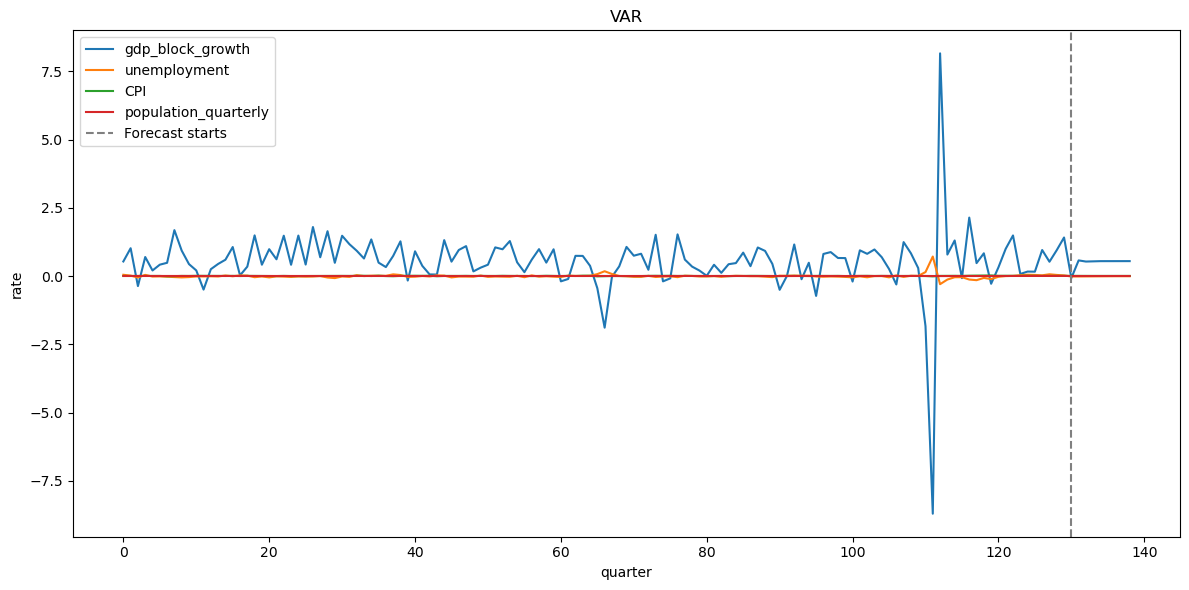

In [13]:
import matplotlib.pyplot as plt
model = VAR(Y_use)
results = model.fit(p)


forecast_steps = 8
forecast_values = results.forecast(y=Y_use.values[-p:], steps=forecast_steps)


forecast_index = pd.RangeIndex(start=Y_use.index[-1] + 1, stop=Y_use.index[-1] + 1 + forecast_steps)
forecast_df = pd.DataFrame(forecast_values, index=forecast_index, columns=Y_use.columns)


plot_df = pd.concat([Y_use, forecast_df])


plt.figure(figsize=(12, 6))
for col in Y_use.columns:
    plt.plot(plot_df.index, plot_df[col], label=col)


plt.axvline(x=Y_use.index[-1], color='gray', linestyle='--', label='Forecast starts')


plt.title("VAR")
plt.xlabel("quarter")
plt.ylabel("rate")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
Y_use.std()

gdp_block_growth        1.217541
unemployment            0.079509
CPI                     0.004721
population_quarterly    0.001606
dtype: float64

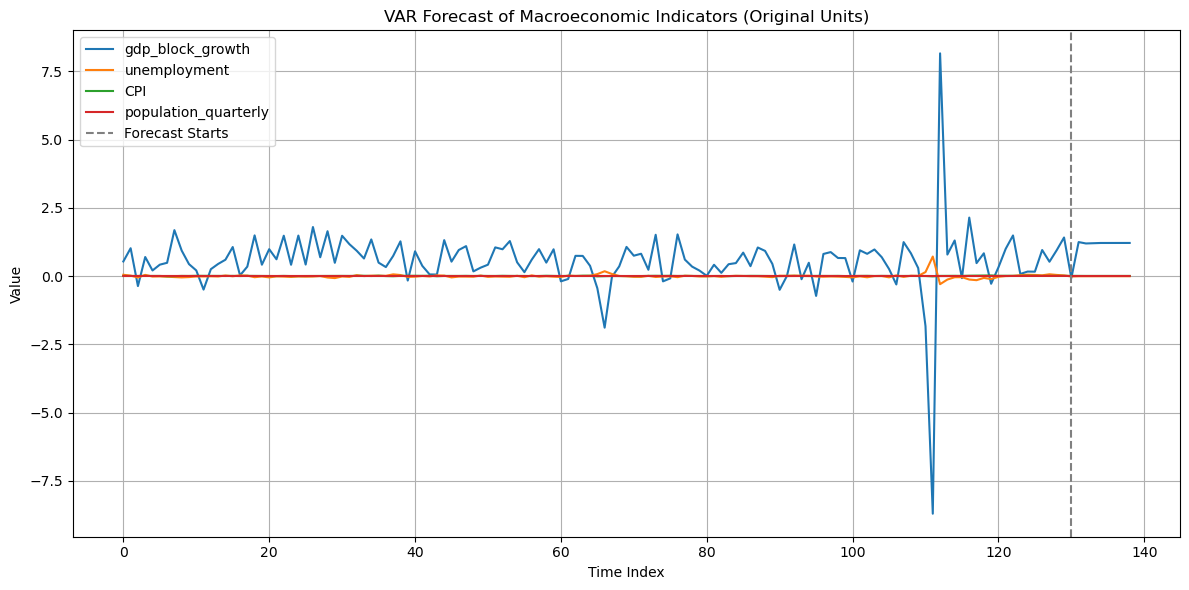

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.api import VAR

# === Step 1: Prepare the data ===
# Drop non-numeric columns (e.g., quarter)
Y_use = df_var_transformed.drop(columns=["quarter"])

# Standardize the data using training sample
scaler = StandardScaler()
Y_scaled = pd.DataFrame(
    scaler.fit_transform(Y_use),
    index=Y_use.index,
    columns=Y_use.columns
)

# === Step 2: Fit the VAR model ===
T, k = len(Y_use), Y_use.shape[1]
p_cap = max(1, min(8, int((T - 2) // (k + 1))))  # BIC cap
sel = VAR(Y_use).select_order(maxlags=p_cap)
p = int(max(1, sel.selected_orders.get("bic") or 1))  # fallback to 1

model = VAR(Y_use)
fit = model.fit(p)

# === Step 3: Forecast the next 8 quarters ===
n_forecast = 8
Y_forecast = fit.forecast(y=Y_use.values[-p:], steps=n_forecast)
Y_forecast = pd.DataFrame(Y_forecast, columns=Y_use.columns)

# === Step 4: Set index for forecast and inverse transform ===
Y_forecast.index = range(Y_use.index[-1] + 1, Y_use.index[-1] + 1 + n_forecast)
Y_forecast_unscaled = pd.DataFrame(
    scaler.inverse_transform(Y_forecast),
    index=Y_forecast.index,
    columns=Y_forecast.columns
)

# === Step 5: Combine historical + forecast (in original units) ===
combined = pd.concat([Y_use, Y_forecast_unscaled])

# === Step 6: Plot ===
plt.figure(figsize=(12, 6))
for col in combined.columns:
    plt.plot(combined.index, combined[col], label=col)

# Add vertical line at forecast start
plt.axvline(x=Y_use.index[-1], color='gray', linestyle='--', label='Forecast Starts')

# Add labels and title
plt.title("VAR Forecast of Macroeconomic Indicators (Original Units)")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Extract existing quarters and generate new ones
from pandas.tseries.offsets import QuarterBegin

# Assume your original df_var_transformed has a 'quarter' column with 'YYYYQx' format
original_quarters = df_var_transformed["quarter"].tolist()

# Convert to datetime index (approximate using first day of quarter)
def quarter_to_date(qstr):
    year = int(qstr[:4])
    quarter = int(qstr[-1])
    month = (quarter - 1) * 3 + 1
    return pd.Timestamp(year=year, month=month, day=1)

last_date = quarter_to_date(original_quarters[-1])
new_dates = [last_date + QuarterBegin(n=i+1) for i in range(n_forecast)]
new_quarters = [f"{d.year}Q{(d.month - 1)//3 + 1}" for d in new_dates]

# Combine existing and new quarter labels
quarter_full = original_quarters + new_quarters
combined["quarter"] = quarter_full

# Reorder columns to put quarter first
combined = combined[["quarter"] + [col for col in combined.columns if col != "quarter"]]

# Save to CSV
combined.to_csv("var_forecast_results_with_quarters.csv", index=False)